# Notebook 02 -- Multivariate EDA & Cross-Correlations

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub -- Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-03

---

### Purpose

This notebook examines the **relationships between the target variable** (foreign overnight stays in Poland) **and each candidate exogenous variable**, moving beyond the univariate descriptions of Notebook 01. The analysis generates the cross-variable evidence needed for Chapter 4 of the thesis and prepares the ground for formal variable selection in Notebook 03.

The notebook covers:

1. **Preliminary construction of the relative tourism price** (Song et al., 2010) to assess price-competitiveness dynamics.
2. **Pairwise correlation analysis** between the target and every candidate predictor, using both Pearson and Spearman coefficients.
3. **Cross-correlation with lags** (0 to 12 months) between the target and each exogenous variable, following the approach of Xie et al. (2021), to identify the optimal lag for each predictor.
4. **Scatter plots and relationship visualisation** for the strongest candidate predictors.
5. **COVID-19 impact comparison** across all variables to assess recovery synchronicity.

**Scope boundaries:** No formal statistical tests (Notebook 03), no feature engineering (Notebook 04), and no modelling (Notebooks 05-08).

**Prerequisite:** Notebooks 00 and 01 must have been run first.

---

## 0. Environment & Configuration

In [68]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.signal import detrend

# --- PLOT SETTINGS ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'savefig.bbox': 'tight',
    'savefig.dpi': 200,
    'savefig.facecolor': 'white',
})

COLORS = {
    'primary':   '#2c3e50',
    'secondary': '#e74c3c',
    'accent1':   '#3498db',
    'accent2':   '#2ecc71',
    'accent3':   '#f39c12',
    'accent4':   '#9b59b6',
    'gray':      '#95a5a6',
    'covid':     '#e74c3c',
}

COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-06-30')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Environment ready.')

Environment ready.


In [69]:
# --- PROJECT PATHS ---
DATA_RAW = os.path.join('..', 'data', 'raw')
FIGURES  = os.path.join('..', 'figures', 'correlations')
os.makedirs(FIGURES, exist_ok=True)

FILES = {
    'nights':       os.path.join(DATA_RAW, 'tourism',
                        'tour_occ_nights_accommodation_PL_2003-.csv'),
    'hicp_m':       os.path.join(DATA_RAW, 'economic',
                        'prc_hicp_midx__relevant-countries-2011-.csv'),
    'exr':          os.path.join(DATA_RAW, 'economic',
                        'ert_bil_eur_m__exchange-rates-eur-pln-usd-2003-.csv'),
    'gdp_real':     os.path.join(DATA_RAW, 'economic',
                        'namq_10_gdp__real-gdp-CLV-2010.csv'),
    'cci':          os.path.join(DATA_RAW, 'demographic',
                        'ei_bsco_m__consumer-conf-indicator.csv'),
    'avia_seats':   os.path.join(DATA_RAW, 'transport',
                        'avia_tf_aca__seats-flights-pass-PL-2010-.csv'),
    'avia_pax':     os.path.join(DATA_RAW, 'transport',
                        'avia_paoc__passengers-countries.csv'),
}

print('File verification:')
for name, path in FILES.items():
    tag = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{tag}] {name}: {os.path.basename(path)}')

File verification:
  [OK] nights: tour_occ_nights_accommodation_PL_2003-.csv
  [OK] hicp_m: prc_hicp_midx__relevant-countries-2011-.csv
  [OK] exr: ert_bil_eur_m__exchange-rates-eur-pln-usd-2003-.csv
  [OK] gdp_real: namq_10_gdp__real-gdp-CLV-2010.csv
  [OK] cci: ei_bsco_m__consumer-conf-indicator.csv
  [OK] avia_seats: avia_tf_aca__seats-flights-pass-PL-2010-.csv
  [OK] avia_pax: avia_paoc__passengers-countries.csv


### 0.1 Helper Functions

In [70]:
# --- COUNTRY MAPPINGS ---
NAME_TO_CODE = {
    'Austria': 'AT', 'Croatia': 'HR', 'Czechia': 'CZ',
    'France': 'FR', 'Germany': 'DE', 'Greece': 'EL',
    'Hungary': 'HU', 'Italy': 'IT', 'Netherlands': 'NL',
    'Poland': 'PL', 'Spain': 'ES', 'Sweden': 'SE',
    'United Kingdom': 'UK', 'United States': 'US',
}
CODE_TO_NAME = {v: k for k, v in NAME_TO_CODE.items()}

CURRENCY_MAP = {
    'Polish zloty': 'PLN', 'Pound sterling': 'GBP',
    'Swedish krona': 'SEK', 'Czech koruna': 'CZK',
    'Hungarian forint': 'HUF', 'US dollar': 'USD',
}

# Countries whose exchange rate matters (non-Eurozone origins)
NON_EURO = {'UK': 'GBP', 'SE': 'SEK', 'CZ': 'CZK', 'HU': 'HUF'}

# Main origin countries for the model
ORIGINS = ['DE', 'UK', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ']


def load_eurostat(path, parse_dates=True):
    """Load Eurostat CSV, parsing TIME_PERIOD to datetime."""
    df = pd.read_csv(path)
    if parse_dates and 'TIME_PERIOD' in df.columns:
        tp = df['TIME_PERIOD'].astype(str)
        if tp.str.match(r'^\d{4}-\d{2}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y-%m')
        elif tp.str.match(r'^\d{4}-Q\d$').all():
            df['date'] = pd.PeriodIndex(tp, freq='Q').to_timestamp()
        elif tp.str.match(r'^\d{4}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y')
        else:
            df['date'] = pd.to_datetime(tp, errors='coerce')
    if 'geo' in df.columns:
        df['iso'] = df['geo'].map(NAME_TO_CODE)
    return df


def covid_shade(ax):
    """Add COVID-19 period shading."""
    ax.axvspan(COVID_START, COVID_END, alpha=0.10, color=COLORS['covid'],
               label='COVID-19 period')


def format_year_axis(ax, interval=2):
    """Format x-axis with year ticks."""
    ax.xaxis.set_major_locator(mdates.YearLocator(interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def savefig(name):
    """Save figure to figures/correlations/."""
    plt.savefig(os.path.join(FIGURES, name))


print('Helpers defined.')

Helpers defined.


---

## 1. Data Loading & Preparation

We load every variable and align them to a common monthly date index covering the study period (2011-01 to 2025-11). GDP is quarterly and will be linearly interpolated to monthly for the correlation analysis. The full cubic spline interpolation is deferred to Notebook 04 (Feature Engineering).

### 1.1 Target Variable

In [71]:
# --- TARGET: Foreign overnight stays ---
df_raw = load_eurostat(FILES['nights'])

ACCOM_TOTAL = ('Hotels; holiday and other short-stay accommodation; '
               'camping grounds, recreational vehicle parks and trailer parks')

mask = (
    (df_raw['geo'] == 'Poland') &
    (df_raw['c_resid'] == 'Foreign country') &
    (df_raw['unit'] == 'Number') &
    (df_raw['nace_r2'] == ACCOM_TOTAL)
)
ts_nights = (
    df_raw.loc[mask].set_index('date')['OBS_VALUE']
    .sort_index().rename('nights')
)
ts_nights = ts_nights[ts_nights.index >= '2011-01-01']

print(f'Target: {len(ts_nights)} obs, {ts_nights.index.min():%Y-%m} -> {ts_nights.index.max():%Y-%m}')

Target: 179 obs, 2011-01 -> 2025-11


### 1.2 HICP (All Countries)

In [72]:
# --- HICP: monthly index for all countries ---
df_hicp = load_eurostat(FILES['hicp_m'])

# Pivot to wide format: columns = country ISO codes, values = HICP index
hicp_wide = (
    df_hicp[df_hicp['iso'].notna()]
    .pivot_table(index='date', columns='iso', values='OBS_VALUE')
    .sort_index()
)
hicp_wide = hicp_wide[hicp_wide.index >= '2011-01-01']

print(f'HICP: {hicp_wide.shape[0]} months x {hicp_wide.shape[1]} countries')
print(f'Countries: {sorted(hicp_wide.columns.tolist())}')

HICP: 180 months x 14 countries
Countries: ['AT', 'CZ', 'DE', 'EL', 'ES', 'FR', 'HR', 'HU', 'IT', 'NL', 'PL', 'SE', 'UK', 'US']


### 1.3 Exchange Rates

In [73]:
# --- EXCHANGE RATES: monthly, national currency per EUR ---
df_exr = load_eurostat(FILES['exr'])

# Map full currency names to ISO codes
df_exr['curr_iso'] = df_exr['currency'].map(CURRENCY_MAP)

exr_wide = (
    df_exr[df_exr['curr_iso'].notna()]
    .pivot_table(index='date', columns='curr_iso', values='OBS_VALUE')
    .sort_index()
)
exr_wide = exr_wide[exr_wide.index >= '2011-01-01']

print(f'Exchange rates: {exr_wide.shape[0]} months x {list(exr_wide.columns)}')

Exchange rates: 182 months x ['CZK', 'GBP', 'HUF', 'PLN', 'SEK', 'USD']


### 1.4 Real GDP (Quarterly -> Monthly)

In [74]:
# --- GDP: quarterly, chain-linked volumes (2010) ---
# Linear interpolation to monthly for correlation analysis.
# Full cubic spline interpolation in Notebook 04.
df_gdp = load_eurostat(FILES['gdp_real'])

gdp_wide = (
    df_gdp[df_gdp['iso'].notna()]
    .pivot_table(index='date', columns='iso', values='OBS_VALUE')
    .sort_index()
)

# Resample to monthly and interpolate linearly
gdp_monthly = gdp_wide.resample('MS').interpolate(method='linear')
gdp_monthly = gdp_monthly[gdp_monthly.index >= '2011-01-01']

print(f'GDP (monthly interpolated): {gdp_monthly.shape[0]} months x {gdp_monthly.shape[1]} countries')

GDP (monthly interpolated): 178 months x 12 countries


### 1.5 Consumer Confidence

In [75]:
# --- CONSUMER CONFIDENCE: monthly balance indicator ---
df_cci = load_eurostat(FILES['cci'])

cci_wide = (
    df_cci[df_cci['iso'].notna()]
    .pivot_table(index='date', columns='iso', values='OBS_VALUE')
    .sort_index()
)
cci_wide = cci_wide[cci_wide.index >= '2011-01-01']

print(f'CCI: {cci_wide.shape[0]} months x {cci_wide.shape[1]} countries')

CCI: 182 months x 12 countries


### 1.6 Airline Seats Available

In [76]:
# --- SEATS: monthly, aggregated across all Polish airports ---
df_avia = load_eurostat(FILES['avia_seats'])

ts_seats = (
    df_avia[df_avia['tra_meas'] == 'Passengers seats available']
    .groupby('date')['OBS_VALUE'].sum()
    .sort_index().rename('seats')
)
ts_seats = ts_seats[ts_seats.index >= '2011-01-01']

print(f'Seats: {len(ts_seats)} months')

Seats: 178 months


---

## 2. Preliminary Construction of the Relative Tourism Price

Following Song et al. (2010), the relative tourism price for origin country $i$ is:

$$P_{it} = \frac{HICP_{PL}}{HICP_i} \times \frac{EX_i}{EX_{PL}}$$

For Eurozone origins (DE, FR, NL, IT, ES, AT), both $EX_i$ and $EX_{PL}$ are expressed against EUR, so the exchange rate component simplifies to $1 / EX_{PL}$ (since $EX_i = 1$ for euro countries). For non-Eurozone origins (UK, SE, CZ, HU), the full bilateral ratio applies.

A rise in $P_{it}$ means Poland has become **relatively more expensive** for tourists from country $i$, which should reduce demand.

In [77]:
# --- BUILD RELATIVE PRICE FOR EACH ORIGIN ---
# For Eurozone countries: P_it = (HICP_PL / HICP_i) * (1 / EX_PLN)
# For non-Euro countries: P_it = (HICP_PL / HICP_i) * (EX_i / EX_PLN)

# Common date range where all series overlap
common_idx = hicp_wide.index.intersection(exr_wide.index)

hicp_pl = hicp_wide.loc[common_idx, 'PL']
exr_pln = exr_wide.loc[common_idx, 'PLN']  # PLN per EUR

rel_price = pd.DataFrame(index=common_idx)

for iso in ORIGINS:
    if iso not in hicp_wide.columns:
        print(f'  {iso}: missing from HICP, skipping')
        continue

    hicp_ratio = hicp_pl / hicp_wide.loc[common_idx, iso]

    if iso in NON_EURO:
        # Non-Eurozone: need the origin's exchange rate too
        curr = NON_EURO[iso]
        if curr in exr_wide.columns:
            exr_origin = exr_wide.loc[common_idx, curr]
            exr_ratio = exr_origin / exr_pln
        else:
            print(f'  {iso}: currency {curr} missing, using HICP ratio only')
            exr_ratio = 1.0 / exr_pln
    else:
        # Eurozone: EX_i = 1 (the origin uses EUR)
        exr_ratio = 1.0 / exr_pln

    rel_price[f'relprice_{iso}'] = hicp_ratio * exr_ratio

print(f'Relative prices computed for: {[c.replace("relprice_", "") for c in rel_price.columns]}')
print(f'Period: {rel_price.index.min():%Y-%m} -> {rel_price.index.max():%Y-%m}')

Relative prices computed for: ['DE', 'UK', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ']
Period: 2011-01 -> 2025-12


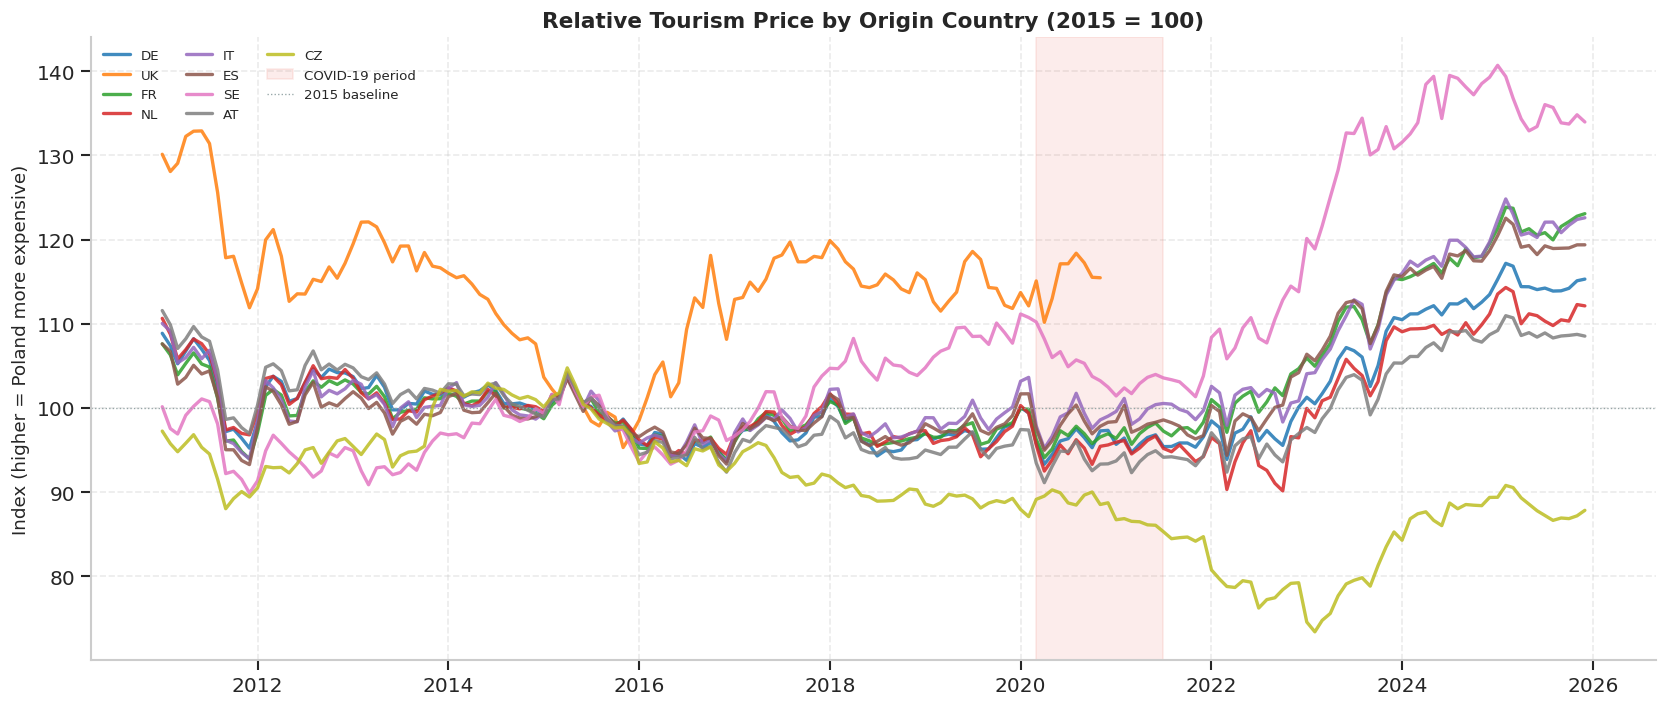

Interpretation: values above 100 indicate Poland has become
relatively MORE expensive vs 2015 for tourists from that country.


In [78]:
# --- PLOT: Relative tourism price evolution ---
fig, ax = plt.subplots(figsize=(14, 6))

for col in rel_price.columns:
    iso = col.replace('relprice_', '')
    # Rebase to 2015 = 100 for visual comparability
    s = rel_price[col]
    base = s[(s.index >= '2015-01-01') & (s.index < '2016-01-01')].mean()
    if base > 0:
        ax.plot(s.index, (s / base) * 100, label=iso, alpha=0.85)

covid_shade(ax)
ax.axhline(100, ls=':', color=COLORS['gray'], lw=0.8, label='2015 baseline')
ax.set_title('Relative Tourism Price by Origin Country (2015 = 100)')
ax.set_ylabel('Index (higher = Poland more expensive)')
ax.legend(ncol=3, loc='upper left', fontsize=8)
format_year_axis(ax)
plt.tight_layout()
savefig('01_relative_price_evolution.png')
plt.show()

print('Interpretation: values above 100 indicate Poland has become')
print('relatively MORE expensive vs 2015 for tourists from that country.')

---

## 3. Building the Monthly Panel for Correlation Analysis

We construct a single DataFrame with the target and all candidate predictors aligned to the same monthly index. For multi-country variables (HICP, GDP, CCI), we compute a **weighted average across origin countries**, using air passenger shares from `avia_paoc` as weights, since larger origin markets should have more influence on aggregate demand. We also keep Germany as a standalone predictor given its dominant market share.

In [79]:
# --- COMPUTE ORIGIN-MARKET WEIGHTS from air passenger data ---
df_pax = load_eurostat(FILES['avia_pax'])

# Total passengers per origin over the full period
pax_totals = (
    df_pax[df_pax['iso'].isin(ORIGINS)]
    .groupby('iso')['OBS_VALUE'].sum()
)
pax_weights = (pax_totals / pax_totals.sum()).to_dict()

print('Origin market weights (based on air passenger shares):')
for iso, w in sorted(pax_weights.items(), key=lambda x: -x[1]):
    print(f'  {iso}: {w:.3f}')

Origin market weights (based on air passenger shares):
  ES: 0.198
  DE: 0.195
  UK: 0.188
  FR: 0.144
  IT: 0.135
  NL: 0.066
  SE: 0.032
  AT: 0.029
  CZ: 0.014


In [80]:
# --- BUILD CONSOLIDATED PANEL ---
panel = pd.DataFrame(index=ts_nights.index)
panel['nights'] = ts_nights

# 1) Weighted-average HICP of origins (excluding PL)
origin_hicp_cols = [c for c in ORIGINS if c in hicp_wide.columns]
hicp_origins = hicp_wide[origin_hicp_cols].reindex(panel.index)
weights_arr = np.array([pax_weights.get(c, 0) for c in origin_hicp_cols])
weights_arr = weights_arr / weights_arr.sum()  # renormalise
panel['hicp_origins_wavg'] = hicp_origins.values @ weights_arr
panel['hicp_PL'] = hicp_wide['PL'].reindex(panel.index)

# 2) HICP ratio: Poland vs weighted-average origin
panel['hicp_ratio'] = panel['hicp_PL'] / panel['hicp_origins_wavg']

# 3) PLN/EUR exchange rate
panel['exr_pln'] = exr_wide['PLN'].reindex(panel.index)

# 4) Weighted-average relative tourism price
rp_cols = [c for c in rel_price.columns]
rp_reindexed = rel_price[rp_cols].reindex(panel.index)
rp_isos = [c.replace('relprice_', '') for c in rp_cols]
rp_weights = np.array([pax_weights.get(iso, 0) for iso in rp_isos])
rp_weights = rp_weights / rp_weights.sum()
panel['relprice_wavg'] = rp_reindexed.values @ rp_weights

# 5) Weighted-average GDP of origins
gdp_origin_cols = [c for c in ORIGINS if c in gdp_monthly.columns]
gdp_origins = gdp_monthly[gdp_origin_cols].reindex(panel.index)
gdp_w = np.array([pax_weights.get(c, 0) for c in gdp_origin_cols])
gdp_w = gdp_w / gdp_w.sum()
panel['gdp_origins_wavg'] = gdp_origins.values @ gdp_w

# 6) Germany GDP (single largest market)
if 'DE' in gdp_monthly.columns:
    panel['gdp_DE'] = gdp_monthly['DE'].reindex(panel.index)

# 7) Weighted-average CCI of origins
cci_origin_cols = [c for c in ORIGINS if c in cci_wide.columns]
cci_origins = cci_wide[cci_origin_cols].reindex(panel.index)
cci_w = np.array([pax_weights.get(c, 0) for c in cci_origin_cols])
cci_w = cci_w / cci_w.sum()
panel['cci_origins_wavg'] = cci_origins.values @ cci_w

# 8) Germany CCI
if 'DE' in cci_wide.columns:
    panel['cci_DE'] = cci_wide['DE'].reindex(panel.index)

# 9) Total airline seats
panel['seats'] = ts_seats.reindex(panel.index)

# 10) Year-over-year growth of target (for deseasonalised correlation)
panel['nights_yoy'] = panel['nights'].pct_change(12)

print(f'Panel shape: {panel.shape}')
print(f'Columns: {list(panel.columns)}')
print(f'\nMissing values per column:')
print(panel.isna().sum())

Panel shape: (179, 12)
Columns: ['nights', 'hicp_origins_wavg', 'hicp_PL', 'hicp_ratio', 'exr_pln', 'relprice_wavg', 'gdp_origins_wavg', 'gdp_DE', 'cci_origins_wavg', 'cci_DE', 'seats', 'nights_yoy']

Missing values per column:
nights                0
hicp_origins_wavg    60
hicp_PL               0
hicp_ratio           60
exr_pln               0
relprice_wavg        60
gdp_origins_wavg      1
gdp_DE                1
cci_origins_wavg      1
cci_DE                0
seats                 1
nights_yoy           12
dtype: int64


---

## 4. Contemporaneous Correlation Analysis

We first examine Pearson (linear) and Spearman (rank-based) correlations at lag 0 between the target and each candidate predictor. Both raw levels and year-over-year changes are analysed. The YoY approach is important because many macroeconomic variables share a common upward trend with tourism demand -- this shared trend can inflate raw correlations without implying a genuine causal relationship.

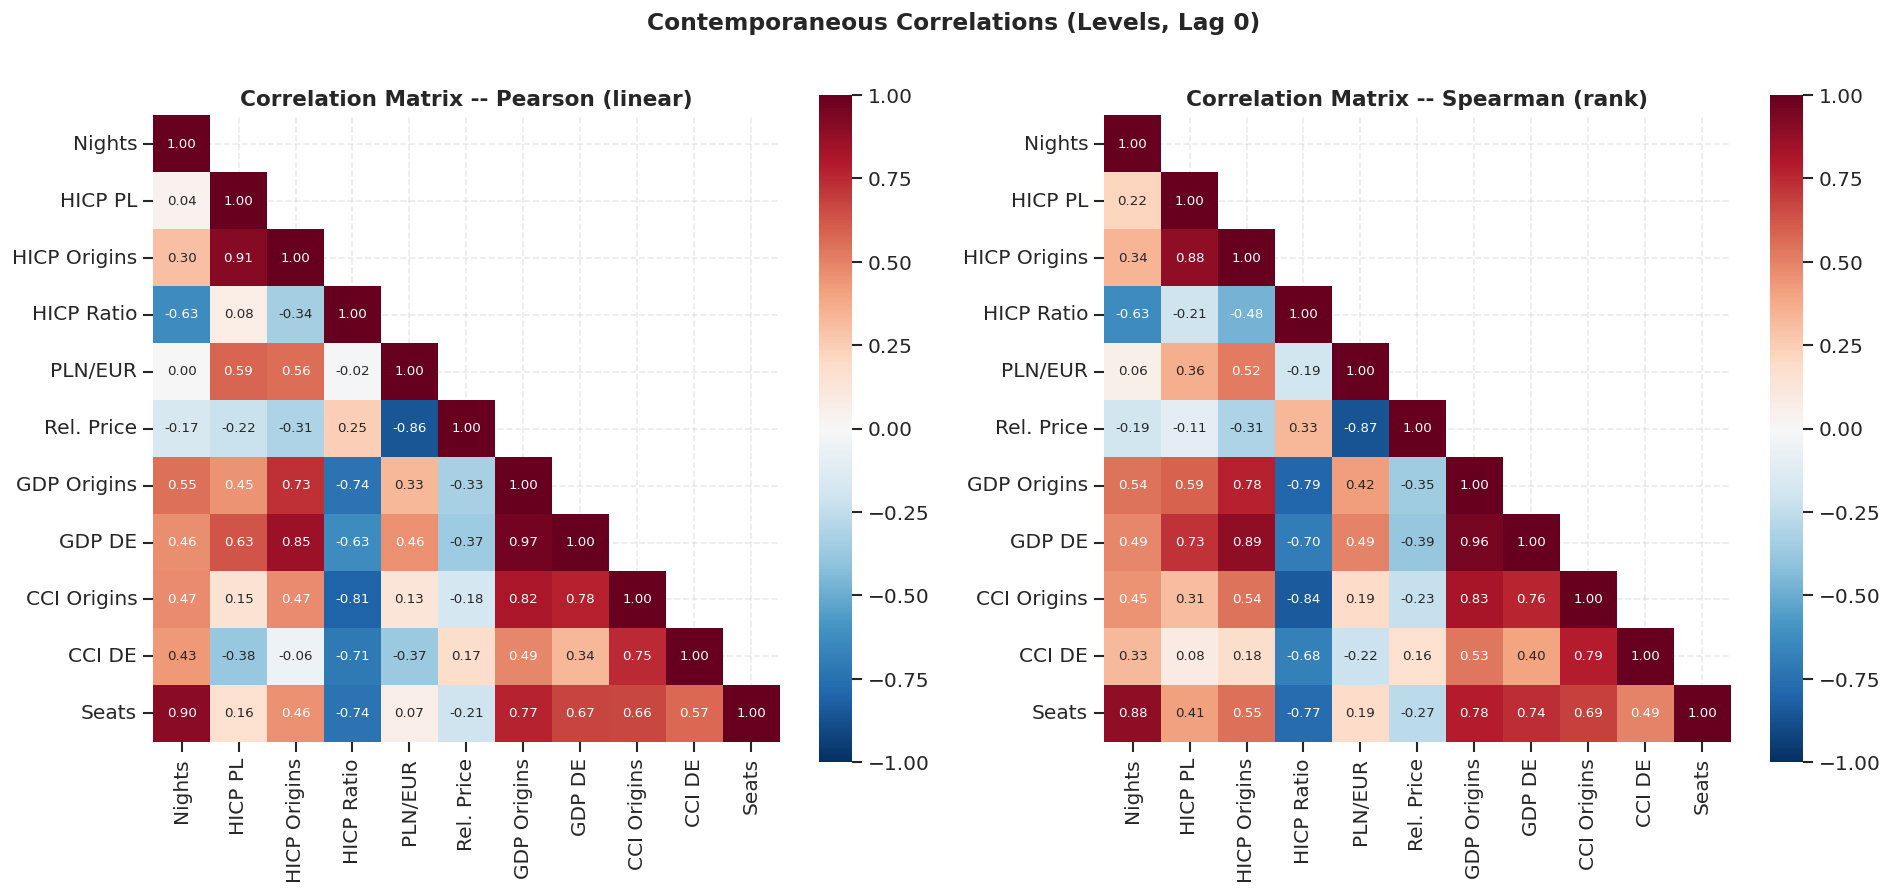

In [81]:
# --- CORRELATION MATRIX (levels) ---
corr_cols = ['nights', 'hicp_PL', 'hicp_origins_wavg', 'hicp_ratio',
             'exr_pln', 'relprice_wavg', 'gdp_origins_wavg', 'gdp_DE',
             'cci_origins_wavg', 'cci_DE', 'seats']

# Only keep columns that exist in the panel
corr_cols = [c for c in corr_cols if c in panel.columns]

corr_pearson = panel[corr_cols].dropna().corr(method='pearson')
corr_spearman = panel[corr_cols].dropna().corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Shorter labels for readability
short_labels = {
    'nights': 'Nights', 'hicp_PL': 'HICP PL', 'hicp_origins_wavg': 'HICP Origins',
    'hicp_ratio': 'HICP Ratio', 'exr_pln': 'PLN/EUR', 'relprice_wavg': 'Rel. Price',
    'gdp_origins_wavg': 'GDP Origins', 'gdp_DE': 'GDP DE',
    'cci_origins_wavg': 'CCI Origins', 'cci_DE': 'CCI DE', 'seats': 'Seats',
}
labels = [short_labels.get(c, c) for c in corr_cols]

for ax, corr, title in zip(axes, [corr_pearson, corr_spearman],
                            ['Pearson (linear)', 'Spearman (rank)']):
    mask_tri = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask_tri, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                xticklabels=labels, yticklabels=labels,
                annot_kws={'size': 8})
    ax.set_title(f'Correlation Matrix -- {title}', fontweight='bold')

plt.suptitle('Contemporaneous Correlations (Levels, Lag 0)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('02_correlation_matrix_levels.png')
plt.show()

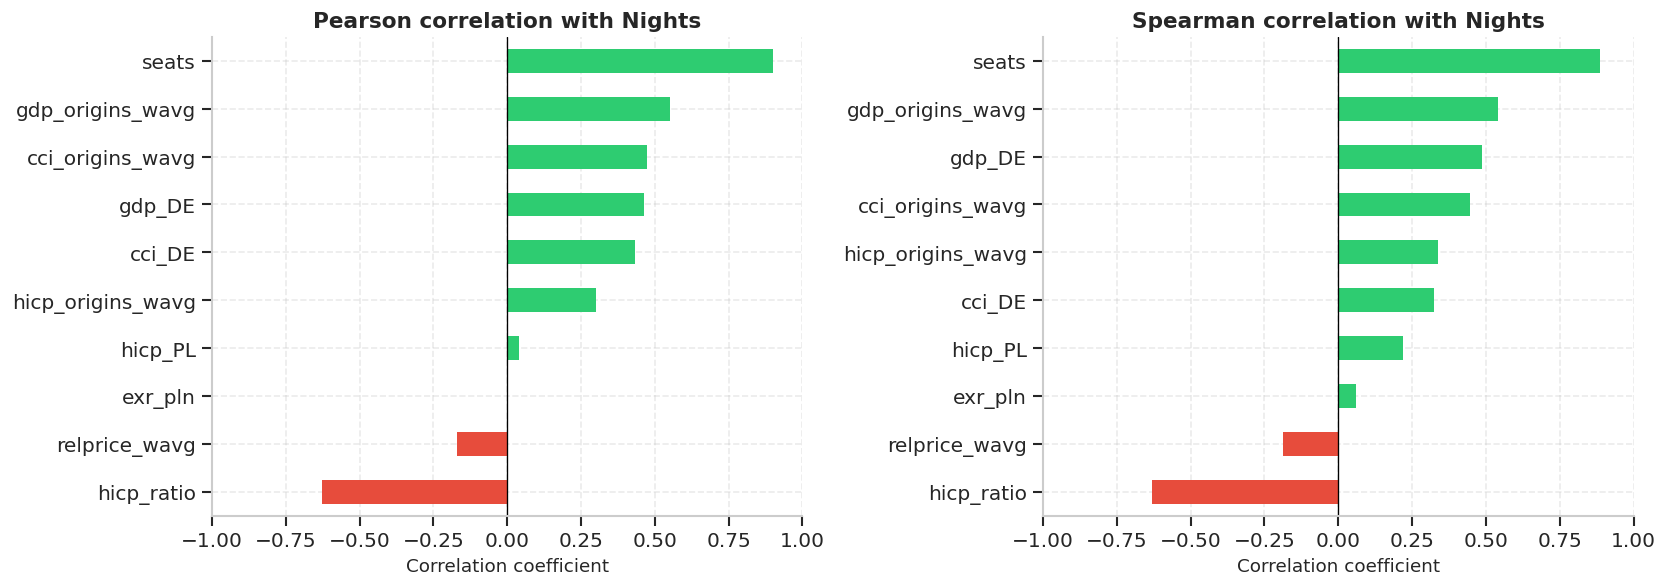

In [82]:
# --- CORRELATION WITH TARGET: sorted bar chart ---
# Extract the 'nights' row from Pearson and Spearman, excluding self-correlation
target_corr_p = corr_pearson.loc['nights'].drop('nights').sort_values()
target_corr_s = corr_spearman.loc['nights'].drop('nights').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tc, title in zip(axes, [target_corr_p, target_corr_s],
                          ['Pearson', 'Spearman']):
    colors = [COLORS['accent2'] if v > 0 else COLORS['secondary'] for v in tc.values]
    tc.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{title} correlation with Nights')
    ax.set_xlabel('Correlation coefficient')
    ax.set_xlim(-1, 1)

plt.tight_layout()
savefig('03_target_correlations_bar.png')
plt.show()

> **Caution on level correlations.** High positive correlations between `nights` and `GDP` or `seats` may be inflated by shared upward trends rather than a genuine economic relationship. The cross-correlation analysis with lags (Section 5) and the YoY transformation provide more reliable evidence.

---

## 5. Cross-Correlation with Lags (0--12 Months)

Following the approach of Xie et al. (2021), we compute the Pearson correlation between the target variable and each candidate predictor at lags 0 through 12 months. The predictor is lagged relative to the target: a lag of $k$ means we correlate `nights(t)` with `predictor(t-k)`, testing whether past values of the predictor are associated with current tourism demand.

This analysis serves two purposes: identifying which variables have the **strongest leading relationship** with demand, and determining the **optimal lag** for each variable -- information that will guide the feature engineering in Notebook 04.

In [83]:
def cross_correlation_lags(target, predictor, max_lag=12):
    """
    Compute Pearson correlation between target(t) and predictor(t-k)
    for k = 0, 1, ..., max_lag.
    
    Returns a Series indexed by lag with correlation values.
    """
    results = {}
    for lag in range(max_lag + 1):
        pred_lagged = predictor.shift(lag)
        # Align and drop NaN
        valid = pd.concat([target, pred_lagged], axis=1).dropna()
        if len(valid) > 20:
            r, p = stats.pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
            results[lag] = r
        else:
            results[lag] = np.nan
    return pd.Series(results, name=predictor.name)


# Variables to test (all candidate predictors in the panel)
predictor_cols = [
    'hicp_ratio', 'exr_pln', 'relprice_wavg',
    'gdp_origins_wavg', 'gdp_DE',
    'cci_origins_wavg', 'cci_DE', 'seats',
]
predictor_cols = [c for c in predictor_cols if c in panel.columns]

# Compute cross-correlations
ccf_results = {}
for col in predictor_cols:
    ccf_results[col] = cross_correlation_lags(
        panel['nights'].dropna(), panel[col].dropna(), max_lag=12
    )

ccf_df = pd.DataFrame(ccf_results)
ccf_df.index.name = 'lag'

print('Cross-correlation results (lag 0 to 12):')
print(ccf_df.round(3).to_string())

Cross-correlation results (lag 0 to 12):
     hicp_ratio  exr_pln  relprice_wavg  gdp_origins_wavg  gdp_DE  cci_origins_wavg  cci_DE  seats
lag                                                                                               
0       -0.6270  -0.0890        -0.1470            0.5010  0.3650            0.1150 -0.0170 0.8800
1       -0.5710  -0.1120        -0.0770            0.5010  0.3620            0.1300  0.0040 0.8260
2       -0.5130  -0.1140        -0.0420            0.4790  0.3440            0.1280  0.0040 0.7110
3       -0.4620  -0.0940        -0.0290            0.4470  0.3230            0.1240 -0.0120 0.5470
4       -0.3990  -0.0610        -0.0360            0.4210  0.3060            0.1240 -0.0280 0.3870
5       -0.3290  -0.0280        -0.0770            0.4110  0.3020            0.1310 -0.0310 0.2690
6       -0.2690   0.0080        -0.1300            0.4150  0.3060            0.1330 -0.0390 0.2200
7       -0.2980   0.0500        -0.2230            0.4250  0.3170   

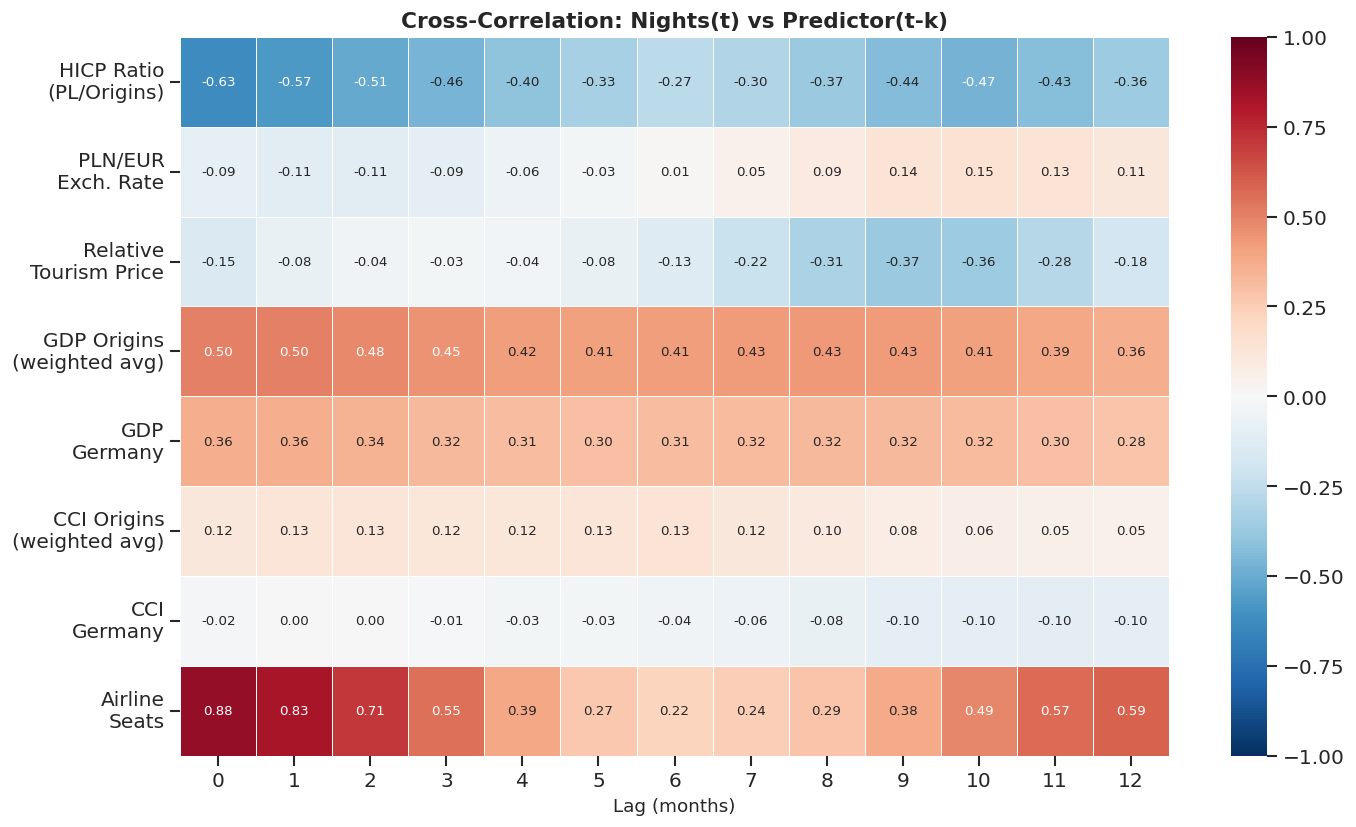

In [84]:
# --- PLOT: Cross-correlation heatmap ---
fig, ax = plt.subplots(figsize=(12, 7))

display_names = {
    'hicp_ratio': 'HICP Ratio\n(PL/Origins)',
    'exr_pln': 'PLN/EUR\nExch. Rate',
    'relprice_wavg': 'Relative\nTourism Price',
    'gdp_origins_wavg': 'GDP Origins\n(weighted avg)',
    'gdp_DE': 'GDP\nGermany',
    'cci_origins_wavg': 'CCI Origins\n(weighted avg)',
    'cci_DE': 'CCI\nGermany',
    'seats': 'Airline\nSeats',
}

ccf_display = ccf_df.rename(columns=display_names)

sns.heatmap(ccf_display.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_xlabel('Lag (months)')
ax.set_ylabel('')
ax.set_title('Cross-Correlation: Nights(t) vs Predictor(t-k)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
savefig('04_cross_correlation_heatmap.png')
plt.show()

In [85]:
# --- OPTIMAL LAG per predictor ---
# The lag with the highest absolute correlation
print('Optimal lag per predictor (highest |correlation|):')
print('=' * 55)
for col in ccf_df.columns:
    abs_corr = ccf_df[col].abs()
    best_lag = abs_corr.idxmax()
    best_val = ccf_df[col].loc[best_lag]
    print(f'  {col:<25s}  lag={best_lag:>2d}  r={best_val:>+.3f}')

Optimal lag per predictor (highest |correlation|):
  hicp_ratio                 lag= 0  r=-0.627
  exr_pln                    lag=10  r=+0.149
  relprice_wavg              lag= 9  r=-0.368
  gdp_origins_wavg           lag= 1  r=+0.501
  gdp_DE                     lag= 0  r=+0.365
  cci_origins_wavg           lag= 6  r=+0.133
  cci_DE                     lag=11  r=-0.105
  seats                      lag= 0  r=+0.880


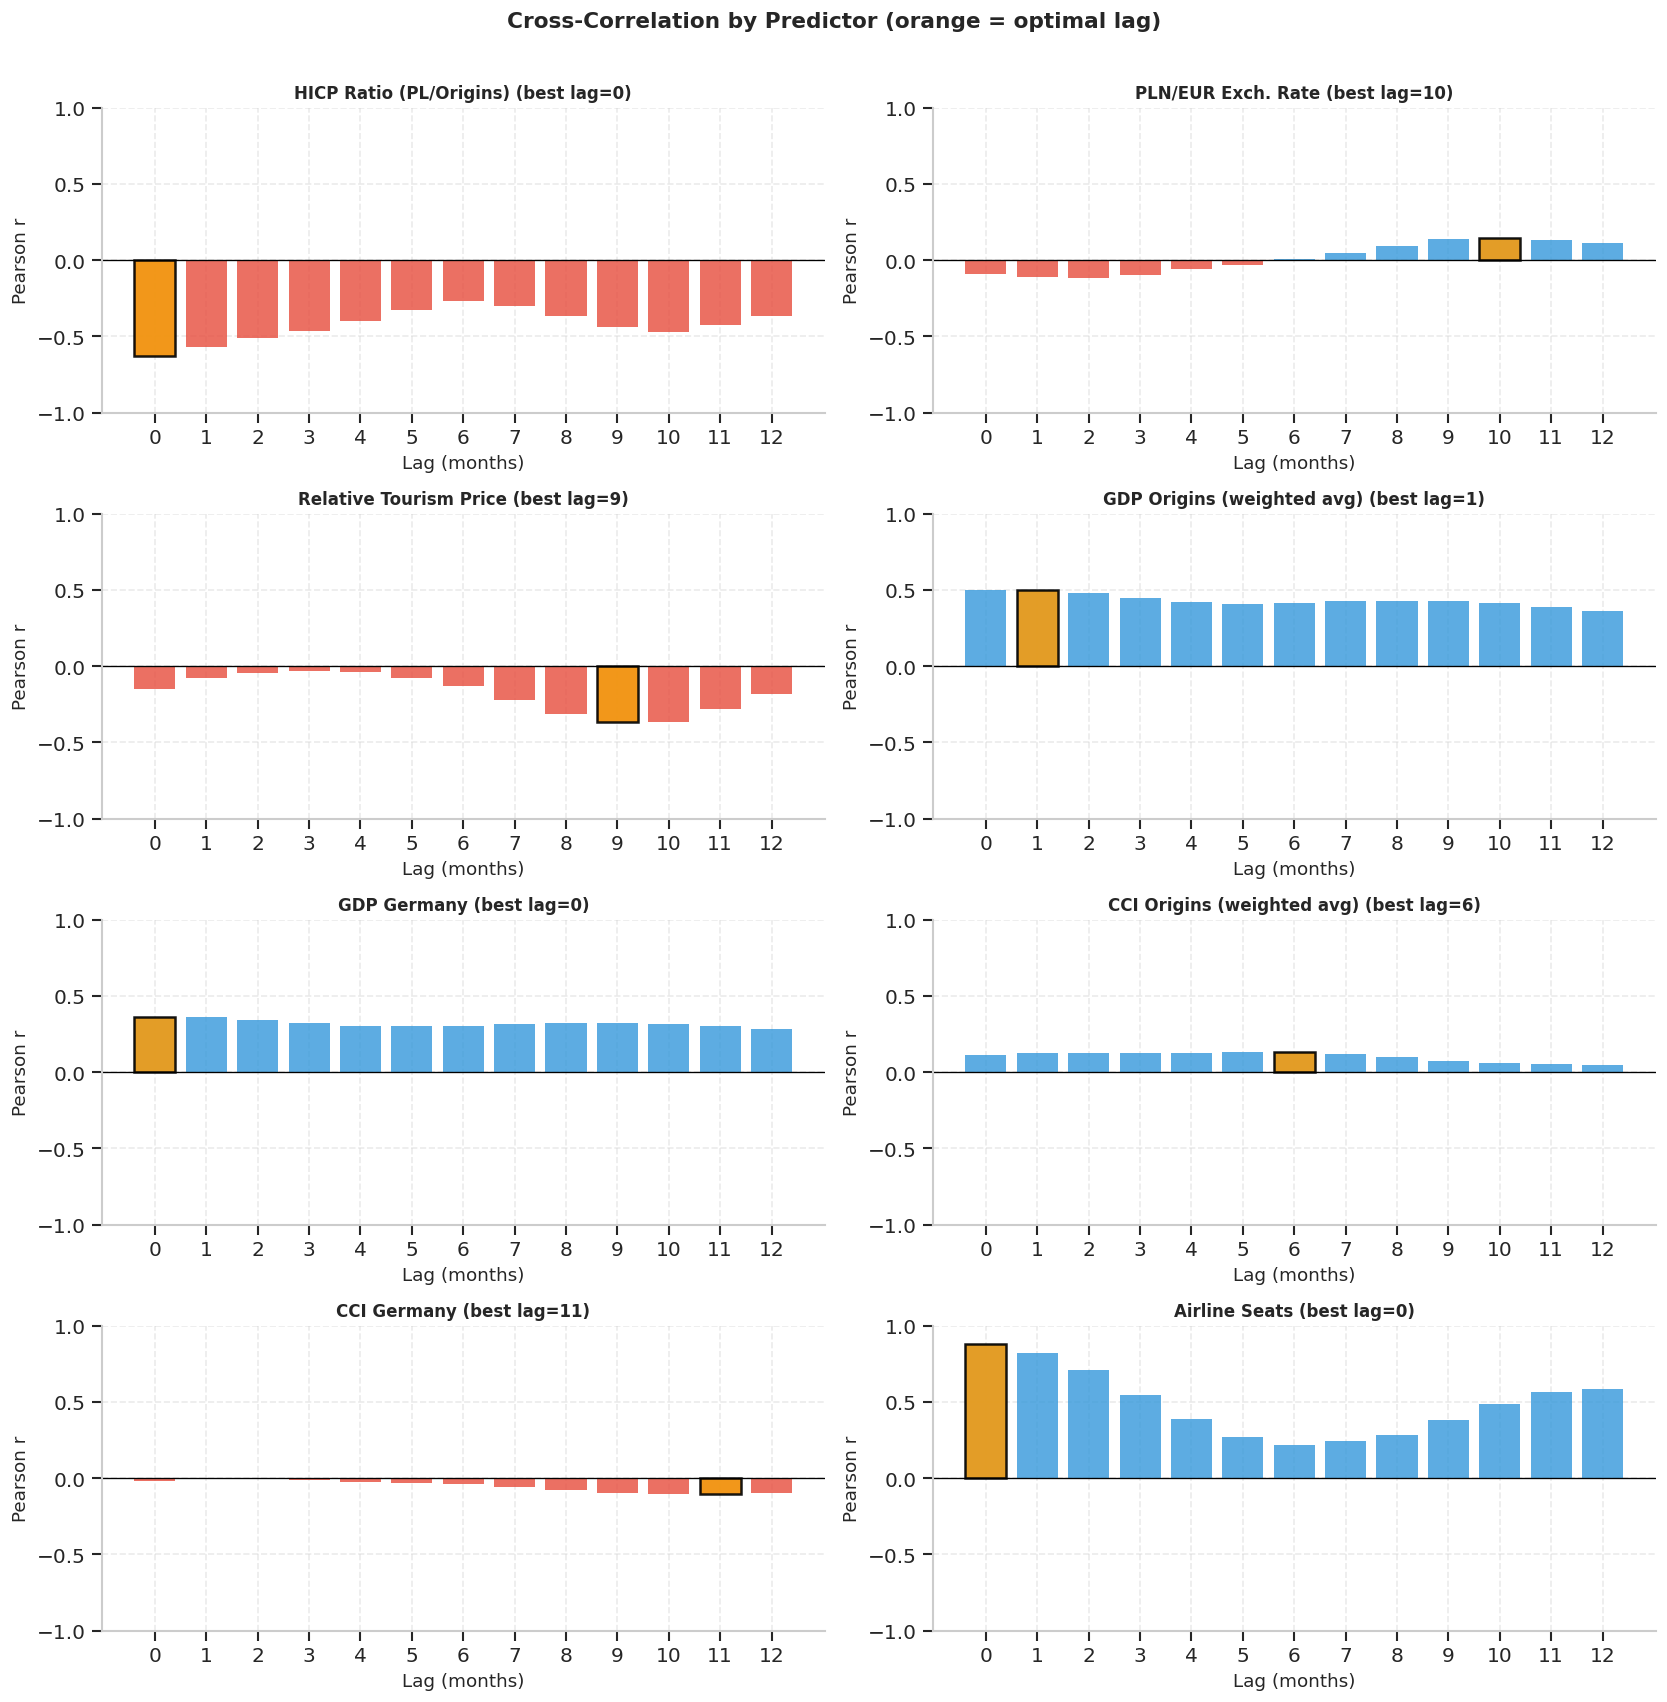

In [86]:
# --- INDIVIDUAL CROSS-CORRELATION PLOTS ---
n_vars = len(predictor_cols)
ncols = 2
nrows = (n_vars + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
axes_flat = axes.flatten()

for i, col in enumerate(predictor_cols):
    ax = axes_flat[i]
    vals = ccf_df[col]
    colors = [COLORS['accent1'] if v >= 0 else COLORS['secondary']
              for v in vals.values]
    ax.bar(vals.index, vals.values, color=colors, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)

    # Mark the optimal lag
    best_lag = vals.abs().idxmax()
    ax.bar(best_lag, vals.loc[best_lag], color=COLORS['accent3'],
           edgecolor='black', lw=1.5, alpha=0.9)

    name = display_names.get(col, col).replace('\n', ' ')
    ax.set_title(f'{name} (best lag={best_lag})', fontsize=10)
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Pearson r')
    ax.set_ylim(-1, 1)
    ax.set_xticks(range(0, 13))

# Hide unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Cross-Correlation by Predictor (orange = optimal lag)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('05_cross_correlation_individual.png')
plt.show()

---

## 6. Year-over-Year Cross-Correlations (Detrended)

The level correlations above are contaminated by shared trends. A more reliable approach is to compute the YoY percentage change for both the target and each predictor, then cross-correlate the **growth rates**. This removes the trend component and focuses on whether *changes* in macroeconomic conditions are associated with *changes* in tourism demand.

In [87]:
# --- YoY PANEL ---
panel_yoy = panel[['nights'] + predictor_cols].pct_change(12).dropna()

# Exclude COVID period for a cleaner signal
panel_yoy_clean = panel_yoy[
    (panel_yoy.index < '2020-01-01') | (panel_yoy.index > '2022-06-01')
]

print(f'YoY panel (excl. COVID): {panel_yoy_clean.shape[0]} months')

YoY panel (excl. COVID): 137 months


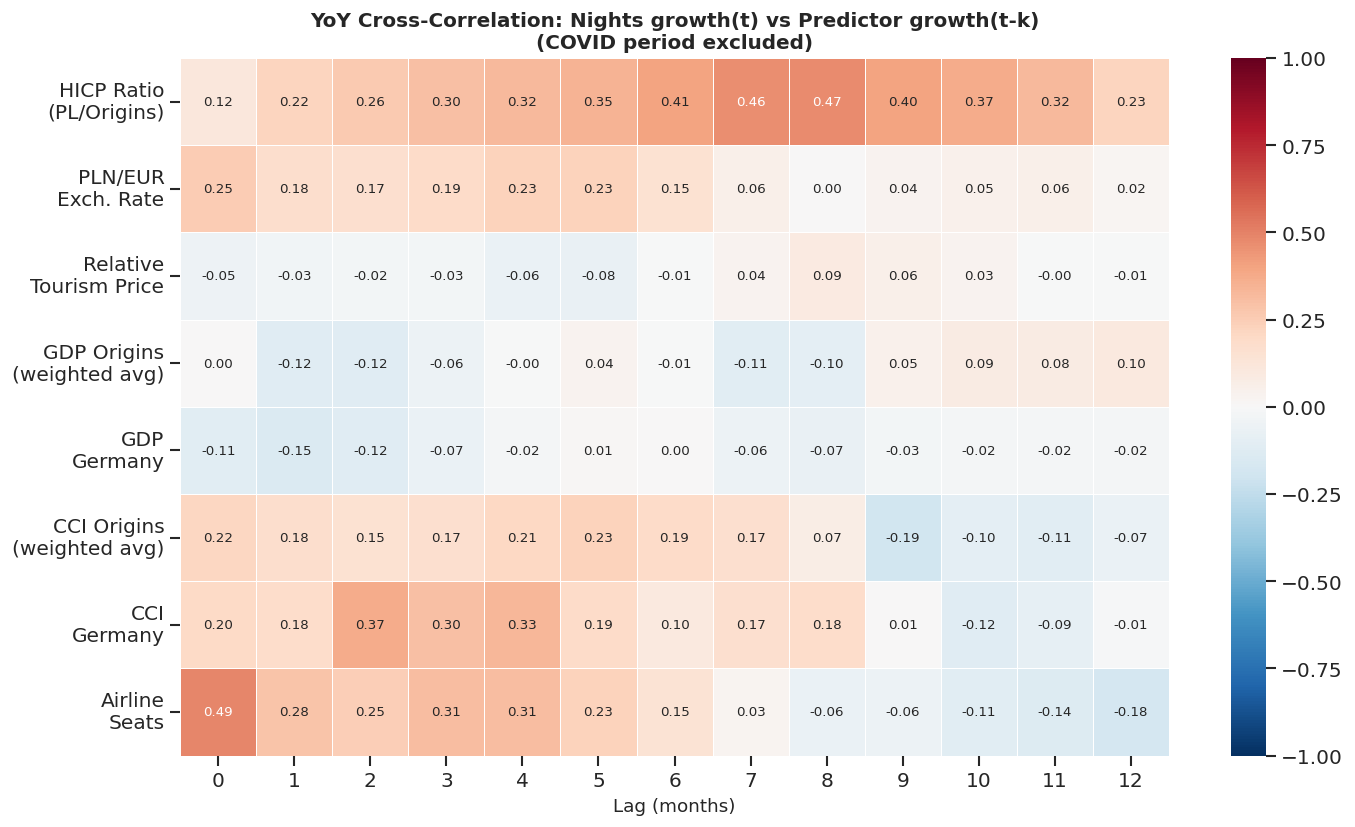


Optimal lags (YoY, excl. COVID):
  hicp_ratio                 lag= 8  r=+0.473
  exr_pln                    lag= 0  r=+0.253
  relprice_wavg              lag= 8  r=+0.090
  gdp_origins_wavg           lag= 2  r=-0.121
  gdp_DE                     lag= 1  r=-0.148
  cci_origins_wavg           lag= 5  r=+0.233
  cci_DE                     lag= 2  r=+0.370
  seats                      lag= 0  r=+0.485


In [88]:
# --- YOY CROSS-CORRELATION WITH LAGS ---
ccf_yoy = {}
for col in predictor_cols:
    valid = pd.concat(
        [panel_yoy_clean['nights'], panel_yoy_clean[col]],
        axis=1
    ).replace([np.inf, -np.inf], np.nan).dropna()

    # Guard against constant/near-constant series after filtering
    if (len(valid) > 20
            and valid.iloc[:, 0].nunique() > 1
            and valid.iloc[:, 1].nunique() > 1):
        ccf_yoy[col] = cross_correlation_lags(
            valid.iloc[:, 0], valid.iloc[:, 1], max_lag=12
        )
    else:
        ccf_yoy[col] = pd.Series(
            {lag: np.nan for lag in range(13)},
            name=col
        )

ccf_yoy_df = pd.DataFrame(ccf_yoy)
ccf_yoy_df.index.name = 'lag'

# Heatmap
fig, ax = plt.subplots(figsize=(12, 7))
ccf_yoy_display = ccf_yoy_df.rename(columns=display_names)
sns.heatmap(ccf_yoy_display.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_xlabel('Lag (months)')
ax.set_ylabel('')
ax.set_title('YoY Cross-Correlation: Nights growth(t) vs Predictor growth(t-k)\n'
             '(COVID period excluded)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
savefig('06_cross_correlation_yoy_heatmap.png')
plt.show()

print('\nOptimal lags (YoY, excl. COVID):')
print('=' * 55)
for col in ccf_yoy_df.columns:
    abs_c = ccf_yoy_df[col].abs()
    best = abs_c.idxmax()
    val = ccf_yoy_df[col].loc[best]
    print(f'  {col:<25s}  lag={best:>2d}  r={val:>+.3f}')

---

## 7. Key Relationship Scatter Plots

Scatter plots visualise the shape of the relationship between the target and the strongest predictors identified above. We plot both raw levels (left) and YoY changes (right) to compare. Points are coloured by year to reveal structural shifts.

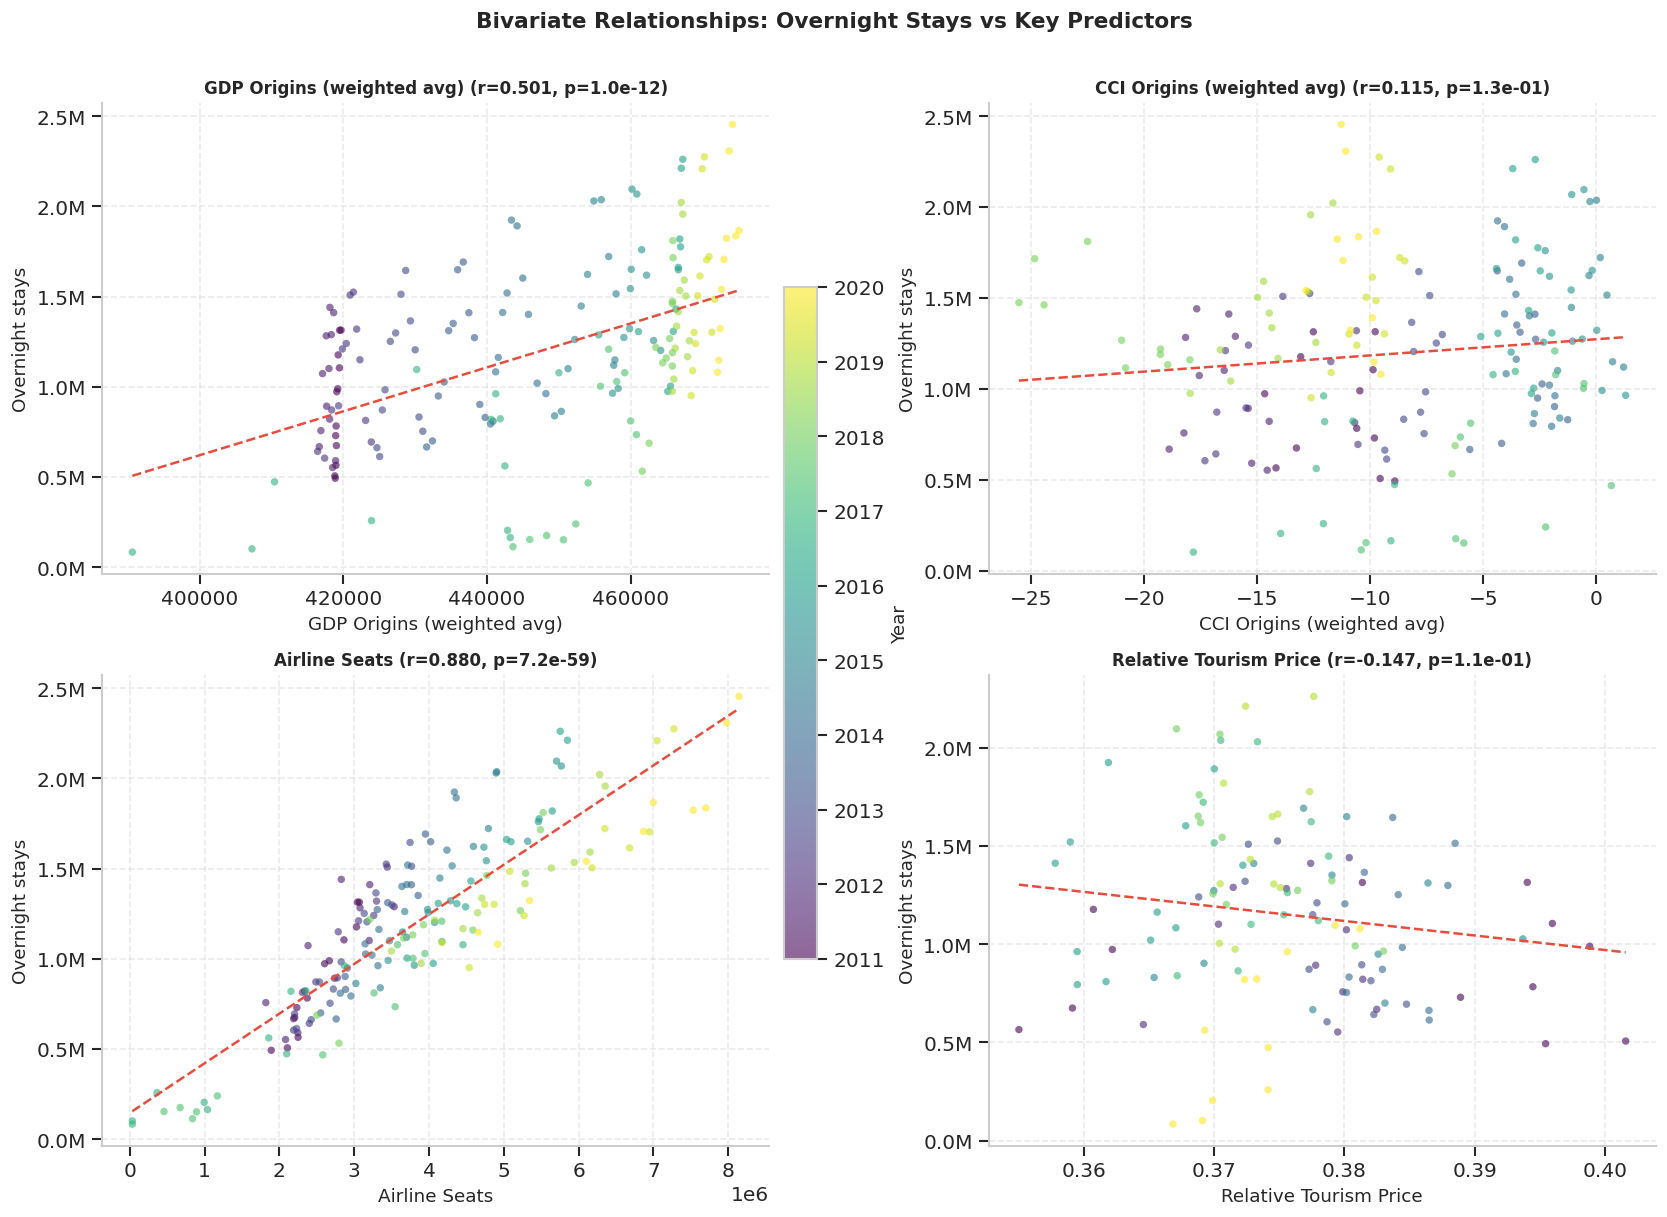

In [89]:
# --- SCATTER: Target vs top predictors ---
scatter_vars = ['gdp_origins_wavg', 'cci_origins_wavg', 'seats', 'relprice_wavg']
scatter_vars = [v for v in scatter_vars if v in panel.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, var in enumerate(scatter_vars):
    ax = axes_flat[i]
    valid = panel[['nights', var]].dropna()

    # Colour by year
    years = valid.index.year
    scatter = ax.scatter(valid[var], valid['nights'],
                         c=years, cmap='viridis', alpha=0.6, s=20,
                         edgecolors='none')

    # Regression line
    z = np.polyfit(valid[var], valid['nights'], 1)
    x_line = np.linspace(valid[var].min(), valid[var].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color=COLORS['secondary'],
            ls='--', lw=1.5)

    r, p = stats.pearsonr(valid[var], valid['nights'])
    name = display_names.get(var, var).replace('\n', ' ')
    ax.set_title(f'{name} (r={r:.3f}, p={p:.1e})', fontsize=10)
    ax.set_xlabel(name)
    ax.set_ylabel('Overnight stays')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M'))

# Colourbar
cbar = fig.colorbar(scatter, ax=axes_flat, shrink=0.35, pad=0.7)
cbar.set_label('Year')
# Set position of colorbar to center
cbar.ax.set_position([0.47, 0.15, 0.02, 0.7])

plt.suptitle('Bivariate Relationships: Overnight Stays vs Key Predictors',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('07_scatter_key_predictors.png')
plt.show()

---

## 8. COVID-19 Impact and Recovery Comparison

Comparing how different variables collapsed and recovered during the pandemic reveals potential asymmetries that could affect model performance. If tourism demand recovered more slowly than economic indicators, models trained on pre-COVID relationships may overpredict during the recovery phase.

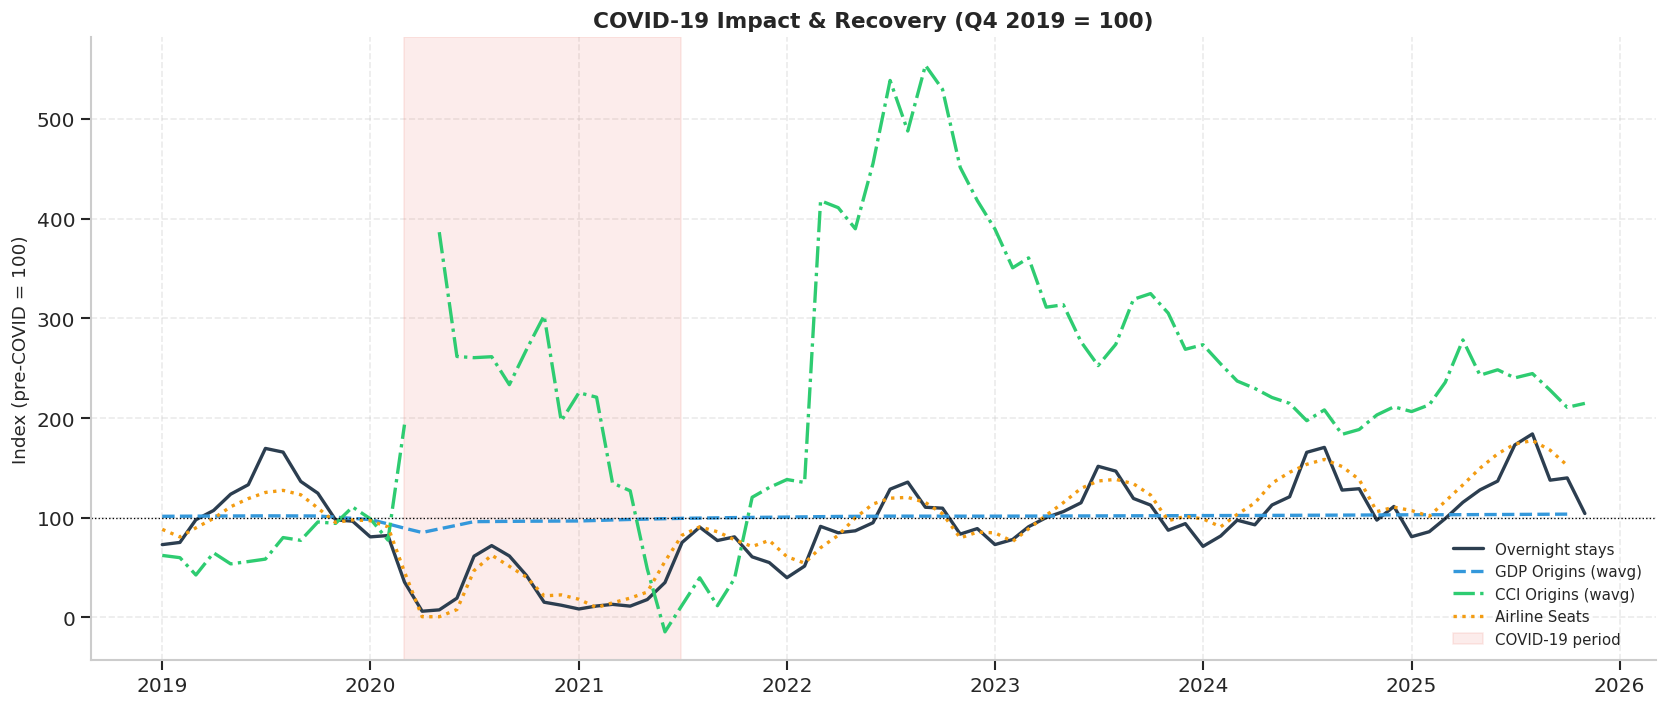

Recovery to pre-COVID levels:
  nights                   : first exceeded baseline in 2022-07
  gdp_origins_wavg         : first exceeded baseline in 2021-10
  cci_origins_wavg         : first exceeded baseline in 2020-07
  seats                    : first exceeded baseline in 2022-06


In [90]:
# --- NORMALISED COVID COMPARISON ---
# Rebase all variables to Jan 2020 = 100
compare_cols = ['nights', 'gdp_origins_wavg', 'cci_origins_wavg', 'seats']
compare_cols = [c for c in compare_cols if c in panel.columns]

# Use a 3-month average around Jan 2020 for a stable base
base_period = panel.loc['2019-10':'2020-01', compare_cols].mean()

normalised = (panel[compare_cols] / base_period) * 100

fig, ax = plt.subplots(figsize=(14, 6))

style_map = {
    'nights': (COLORS['primary'], '-',  'Overnight stays'),
    'gdp_origins_wavg': (COLORS['accent1'], '--', 'GDP Origins (wavg)'),
    'cci_origins_wavg': (COLORS['accent2'], '-.', 'CCI Origins (wavg)'),
    'seats': (COLORS['accent3'], ':', 'Airline Seats'),
}

for col in compare_cols:
    color, ls, label = style_map.get(col, (COLORS['gray'], '-', col))
    s = normalised[col].loc['2019-01':'2025-11']
    ax.plot(s.index, s.values, color=color, ls=ls, label=label)

covid_shade(ax)
ax.axhline(100, color='black', lw=0.8, ls=':')
ax.set_title('COVID-19 Impact & Recovery (Q4 2019 = 100)', fontweight='bold')
ax.set_ylabel('Index (pre-COVID = 100)')
ax.legend(loc='lower right')
format_year_axis(ax, interval=1)
plt.tight_layout()
savefig('08_covid_recovery_comparison.png')
plt.show()

# When did each variable first exceed 100 again?
print('Recovery to pre-COVID levels:')
for col in compare_cols:
    s = normalised[col].loc['2020-07':]
    recovered = s[s >= 100]
    if len(recovered) > 0:
        print(f'  {col:<25s}: first exceeded baseline in {recovered.index[0]:%Y-%m}')
    else:
        print(f'  {col:<25s}: has NOT yet recovered')

---

## 9. Summary of Findings

### 9.1 Cross-Correlation Summary Table

In [91]:
# --- SUMMARY TABLE ---
summary_rows = []
for col in predictor_cols:
    # Level correlations
    abs_level = ccf_df[col].abs()
    best_lag_level = abs_level.idxmax()
    r_level = ccf_df[col].loc[best_lag_level]

    # YoY correlations
    abs_yoy = ccf_yoy_df[col].abs()
    best_lag_yoy = abs_yoy.idxmax()
    r_yoy = ccf_yoy_df[col].loc[best_lag_yoy]

    summary_rows.append({
        'Variable': display_names.get(col, col).replace('\n', ' '),
        'Best lag (levels)': best_lag_level,
        'r (levels)': f'{r_level:+.3f}',
        'Best lag (YoY)': best_lag_yoy,
        'r (YoY)': f'{r_yoy:+.3f}',
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

                  Variable  Best lag (levels) r (levels)  Best lag (YoY) r (YoY)
   HICP Ratio (PL/Origins)                  0     -0.627               8  +0.473
        PLN/EUR Exch. Rate                 10     +0.149               0  +0.253
    Relative Tourism Price                  9     -0.368               8  +0.090
GDP Origins (weighted avg)                  1     +0.501               2  -0.121
               GDP Germany                  0     +0.365               1  -0.148
CCI Origins (weighted avg)                  6     +0.133               5  +0.233
               CCI Germany                 11     -0.105               2  +0.370
             Airline Seats                  0     +0.880               0  +0.485


### 9.2 Key Insights from the Cross-Correlation Analysis

**Finding 1 — Airline seat capacity is the dominant predictor (r=0.880 levels, r=0.485 YoY).** The strength of this relationship persists even after removing shared trends via YoY transformation, suggesting a genuine association rather than a purely spurious trend correlation. However, **endogeneity** remains a concern: airlines adjust capacity based on expected demand. The modelling strategy (Notebook 05 onwards) will address this by using **seats at lags of 6-12 months**, reflecting the IATA slot allocation lead time, where the correlation in levels remains substantial (r=0.22-0.57).

**Finding 2 — The HICP ratio captures price competitiveness effectively (r=-0.627 at lag 0).** The negative sign confirms the theoretical expectation: when Poland becomes relatively more expensive, foreign overnight stays decline. The contemporaneous response (optimal lag = 0) suggests tourists adjust quickly to relative price changes. However, the sign inversion in YoY correlations (+0.473 at lag 8) is a spurious artefact of the post-COVID period, where both Polish inflation and tourism recovery accelerated simultaneously. The level-based correlation is more reliable for this variable.

**Finding 3 — The relative tourism price (Song et al.) is weaker than expected (r=-0.368 at lag 9).** This is consistent with the inelastic price elasticities reported in the meta-analyses of Crouch (1994, 1995): the average price elasticity of international tourism demand ranges from -0.6 to -0.8. For Poland specifically, the structural price advantage (~30% below EU average as shown in the PPP analysis of Notebook 01) means that marginal fluctuations in the relative price have limited impact on travel decisions — the destination remains a "good deal" regardless.

**Finding 4 — GDP works better as a level predictor than as a growth predictor.** The moderate correlation in levels (r=+0.501 at lag 1) but weak and wrongly-signed correlation in YoY (r=-0.121) indicates that GDP captures the secular trend in tourism demand (richer countries send more tourists over time) rather than short-term cyclical fluctuations. This distinction matters for model specification: GDP should enter the model in levels (or log-levels), not in first differences.

**Finding 5 — German consumer confidence is a genuine leading indicator (r=+0.370 in YoY at lag 2).** While the weighted-average CCI across all origins is weak, the German CCI alone shows a meaningful leading relationship: improvements in German consumer sentiment precede growth in Polish tourism by approximately 2 months. Germany's dominant market share (19.5% of air passengers) gives this finding practical significance. The weakness of the weighted average likely reflects the mixing of asynchronous business cycles across origin countries.

**Finding 6 — COVID recovery is asymmetric across variables.** Consumer confidence recovered first (July 2020, only 4 months after the trough), followed by GDP (October 2021, 18 months), airline seats (June 2022, 27 months), and finally overnight stays (July 2022, 28 months). This 2-year lag between sentiment/economic recovery and tourism recovery confirms the existence of a "COVID persistence effect" that pure macroeconomic models would fail to predict, justifying the multi-phase COVID dummy specification.

**Implication for modelling:** The correlation structure suggests that the most informative model will combine **airline seats** (lagged 6-12 months) as the primary predictor with **HICP ratio** (lag 0-1) and **German CCI** (lag 2-3) as secondary predictors, plus **GDP** in levels for trend capture and **autoregressive lags** (t-1, t-12) for seasonal memory. The relative tourism price adds modest incremental information. These hypotheses will be formally tested with Granger causality and BMA in Notebook 03.



### 9.3 Variables and Lags Proposed for Feature Engineering

Based on the cross-correlation analysis, the following variables and lag ranges are proposed for formal testing in Notebook 03 and inclusion in the feature engineering pipeline (Notebook 04):

| Variable | Proposed lag range | Expected sign | Rationale |
|----------|-------------------|---------------|----------|
| GDP origins (weighted avg) | 0--3 months | Positive | Income effect |
| Relative tourism price (weighted avg) | 0--6 months | Negative | Price competitiveness |
| CCI origins (weighted avg) | 2--6 months | Positive | Sentiment leading indicator |
| Airline seats (national total) | 6--12 months | Positive | Predetermined capacity |
| PLN/EUR exchange rate | 0--3 months | Depends on direction | Part of relative price |
| Target lags (t-1, t-12) | 1, 12 months | Positive | Autoregressive / seasonal memory |

### 9.4 Questions for Notebook 03 (Statistical Tests)

1. Are the tourism demand series and the candidate predictors **stationary** or do they require differencing? (ADF tests)
2. Does each candidate variable **Granger-cause** overnight stays at the optimal lag? (Granger causality)
3. Is there a **long-run equilibrium** between demand and its determinants? (Johansen cointegration)
4. What is the **posterior inclusion probability** of each predictor under Bayesian Model Averaging (BMA)?

---

*End of Notebook 02 -- Next: [03_statistical_tests_feature_selection.ipynb](./03_statistical_tests_feature_selection.ipynb)*